# 03. Feature readiness

날짜별 `market_vwap` 타겟과 `02_target_eda.ipynb`의 `nominal_plus_15` 표본을 기준으로, 모델에 넣을 수 있는 feature 후보군을 점검한다.

PostgreSQL `raw`/`meta` 테이블과 `docs/reference/` 문서를 함께 사용한다. \
DB에 있는 원천 컬럼은 넓게 후보로 모으고, 예측 시점에 사용할 수 있는지, target 표본과 기간이 맞는지, 공시 lag 또는 `asof_date` 규칙이 필요한지를 먼저 확인한다.

초기 단계에서는 피처 수를 과도하게 줄이지 않는다. 이후 노트북에서 walk-forward 모델, SHAP, permutation importance, ablation으로 실제 기여도를 판단한다.

## 1. 분석 기준

| 항목 | 정의 |
|---|---|
| `source_inventory` | `meta.table_catalog` 기준 raw source 목록과 기간, 빈도, 대표 날짜 컬럼을 정리한 표이다. |
| `disclosure_rule` | `meta.disclosure_rule_catalog`에 등록된 `asof_date` 또는 공시 lag 사용 규칙이다. |
| `window_coverage` | target 기준일이 source의 관측 기간 안에 들어오는 비율이다. 실제 feature 결측률 점검 전 source 단위 coverage로 사용한다. |
| `feature_candidate_catalog` | raw table의 숫자형/불리언 컬럼을 넓게 모은 후보 목록이다. |
| `reference_mapping` | `docs/reference/피처_엔지니어링.md`, `docs/reference/가격_모델.md`의 아이디어를 현재 DB source와 연결한 표이다. |
| `readiness_status` | 첫 wide feature set 포함 여부를 판단하기 위한 source 단위 상태값이다. |

`readiness_status`는 `use_now`, `derive_now`, `use_with_lag`, `review_required`, `not_available`로 구분한다. \
`use_now`, `derive_now`, `use_with_lag`는 첫 wide feature set 후보로 두고, `review_required`는 공시 시점 검토 후 별도 확장 후보로 둔다.

In [1]:
# C01. 환경 설정 및 경로 정의
from pathlib import Path
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 180)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

TARGET_PATH = PROJECT_ROOT / 'data' / 'processed' / 'targets' / 'market_vwap_targets.parquet'
REFERENCE_DIR = PROJECT_ROOT / 'docs' / 'reference'
OUT_TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables' / 'feature_readiness'
OUT_FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'feature_readiness'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'feature_readiness'
SAVE_OUTPUTS = True

for p in [OUT_TABLE_DIR, OUT_FIG_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f'project_root: {PROJECT_ROOT}')
print(f'target_path exists: {TARGET_PATH.exists()}')
print(f'reference_dir exists: {REFERENCE_DIR.exists()}')

project_root: /mnt/hgfs/Windows/Climate
target_path exists: True
reference_dir exists: True


## 2. DB 접속 및 target 표본

In [2]:
# C02. DB 접속 및 target 표본 로드
def load_env_file(path: Path):
    env = {}
    if not path.exists():
        return env
    for raw_line in path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        env[key.strip()] = value.strip().strip('"').strip("'")
    return env

env = {**load_env_file(PROJECT_ROOT / '.env'), **os.environ}
required = ['DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD']
missing = [k for k in required if not env.get(k)]
if missing:
    raise RuntimeError(f'Missing DB env keys: {missing}')

import psycopg2
conn = psycopg2.connect(
    host=env['DB_HOST'], port=env['DB_PORT'], dbname=env['DB_NAME'],
    user=env['DB_USER'], password=env['DB_PASSWORD'],
)
print('db_connected: True')
print(f'db_name: {env["DB_NAME"]}')
print('db_driver: psycopg2')

if not TARGET_PATH.exists():
    raise FileNotFoundError(TARGET_PATH)

target = pd.read_parquet(TARGET_PATH).sort_values('trd_dd').reset_index(drop=True)
target['trd_dd'] = pd.to_datetime(target['trd_dd'])
target['year'] = target['trd_dd'].dt.year
ELAPSED_CAPS = {'30d': 45, '60d': 75}
for horizon, cap in ELAPSED_CAPS.items():
    target[f'pass_{horizon}'] = (
        target[f'same_panel_{horizon}'].fillna(False)
        & target[f'target_logret_{horizon}'].notna()
        & target[f'actual_elapsed_days_{horizon}'].le(cap)
    )
target['pass_both_targets'] = target['pass_30d'] & target['pass_60d']

target_summary = {
    'n_rows': int(len(target)),
    'date_start': target['trd_dd'].min().date().isoformat(),
    'date_end': target['trd_dd'].max().date().isoformat(),
    'pass_30d': int(target['pass_30d'].sum()),
    'pass_60d': int(target['pass_60d'].sum()),
    'pass_both_targets': int(target['pass_both_targets'].sum()),
}
print(json.dumps(target_summary, ensure_ascii=False, indent=2))
display(target[['trd_dd', 'market_vwap', 'total_trdvol', 'n_vintages', 'is_blended', 'pass_30d', 'pass_60d']].head())

db_connected: True
db_name: allowance
db_driver: psycopg2
{
  "n_rows": 2132,
  "date_start": "2015-01-12",
  "date_end": "2026-04-23",
  "pass_30d": 2094,
  "pass_60d": 2074,
  "pass_both_targets": 2064
}


,trd_dd,market_vwap,total_trdvol,n_vintages,is_blended,pass_30d,pass_60d
0,2015-01-12,"8,185.210084",1190,1,False,False,False
1,2015-01-13,"9,500.000000",50,1,False,False,False
2,2015-01-14,"9,510.000000",100,1,False,False,False
3,2015-01-16,"9,610.000000",40,1,False,False,False
4,2015-10-07,"11,300.000000",12000,1,False,False,True


## 3. DB metadata inventory

`meta.table_catalog`, `meta.column_catalog`, `meta.disclosure_rule_catalog`를 결합해 raw source 단위 inventory를 만든다. \
이후 단계에서 각 source의 기간, 빈도, 날짜 컬럼, `asof_date` 규칙을 함께 사용한다.

In [3]:
# C03. raw/meta inventory 로드
table_catalog = pd.read_sql("""
    select schema_name, table_name, table_kind, source_id, data_category, description_ko,
           frequency, period_start, period_end, row_count_live, column_count_live,
           primary_date_column, unique_key, is_raw_source, is_external_raw, notes
    from meta.table_catalog
    where schema_name = 'raw'
    order by schema_name, table_name
""", conn)

column_catalog = pd.read_sql("""
    select schema_name, table_name, column_name, ordinal_position, db_data_type,
           is_nullable, description_ko, unit, notes, is_documented
    from meta.column_catalog
    where schema_name = 'raw'
    order by schema_name, table_name, ordinal_position
""", conn)

disclosure_rules = pd.read_sql("""
    select schema_name, table_name, source_id, rule_name, frequency,
           feature_date_column, asof_date_column, usable_date_rule,
           confidence, status, notes
    from meta.disclosure_rule_catalog
    order by schema_name, table_name, status, confidence
""", conn)

for col in ['period_start', 'period_end']:
    table_catalog[col] = pd.to_datetime(table_catalog[col], errors='coerce')

disclosure_summary = (
    disclosure_rules.groupby(['schema_name', 'table_name'], dropna=False)
    .agg(
        disclosure_rule_count=('rule_name', 'size'),
        disclosure_rule_names=('rule_name', lambda s: '; '.join(s.dropna().astype(str).unique())),
        disclosure_statuses=('status', lambda s: '; '.join(s.dropna().astype(str).unique())),
        disclosure_confidences=('confidence', lambda s: '; '.join(s.dropna().astype(str).unique())),
        feature_date_columns=('feature_date_column', lambda s: '; '.join(s.dropna().astype(str).unique())),
        asof_date_columns=('asof_date_column', lambda s: '; '.join(s.dropna().astype(str).unique())),
        usable_date_rules=('usable_date_rule', lambda s: '; '.join(s.dropna().astype(str).unique())),
    ).reset_index()
)

source_inventory = table_catalog.merge(disclosure_summary, on=['schema_name', 'table_name'], how='left')
source_inventory['source_table'] = source_inventory['schema_name'] + '.' + source_inventory['table_name']
source_inventory['has_disclosure_rule'] = source_inventory['disclosure_rule_count'].fillna(0).gt(0)
source_inventory['has_active_high_rule'] = source_inventory.apply(
    lambda r: ('active' in str(r.get('disclosure_statuses', ''))) and ('high' in str(r.get('disclosure_confidences', ''))), axis=1
)
source_inventory['has_asof_date_rule'] = source_inventory['asof_date_columns'].fillna('').astype(str).str.len().gt(0)

print(f'raw table count: {len(source_inventory):,}')
print(f'raw column count: {len(column_catalog):,}')
print(f'disclosure rule count: {len(disclosure_rules):,}')
display(source_inventory[['source_table', 'data_category', 'frequency', 'period_start', 'period_end', 'row_count_live', 'primary_date_column', 'has_active_high_rule', 'disclosure_statuses', 'asof_date_columns']])

raw table count: 32
raw column count: 446
disclosure rule count: 32


,source_table,data_category,frequency,period_start,period_end,row_count_live,primary_date_column,has_active_high_rule,disclosure_statuses,asof_date_columns
0,raw.commodities_monthly,COMMODITIES_MONTHLY,monthly,2015-01-01,2026-04-01,136,date,False,requires_review,
1,raw.epsis_fuel_cost_monthly,EPSIS_FUEL_COST_MONTHLY,monthly,2015-01-01,2025-12-01,132,asof_date,True,active,asof_date
2,raw.epsis_power_supply_daily,EPSIS_POWER_SUPPLY_DAILY,daily,2015-01-01,2025-12-31,4018,asof_date,True,active,asof_date
3,raw.epsis_power_trade_volume_monthly,EPSIS_POWER_TRADE_VOLUME_MONTHLY,monthly,2015-01-01,2025-12-01,132,asof_date,True,active,asof_date
4,raw.epsis_smp_monthly,EPSIS_SMP_MONTHLY,monthly,2015-01-01,2025-12-01,132,asof_date,True,active,asof_date
5,raw.eua_daily,EUA_DAILY,daily,2015-01-02,2026-05-04,2912,date,False,requires_review,
6,raw.gir_additional_allocation,GIR_ADDITIONAL_ALLOCATION,annual,NaT,NaT,1371,year,False,requires_review,
7,raw.gir_borrowing,GIR_BORROWING,annual,NaT,NaT,800,year,False,requires_review,
8,raw.gir_cancelled_allocation,GIR_CANCELLED_ALLOCATION,annual,NaT,NaT,9583,year,False,requires_review,
9,raw.gir_carryover,GIR_CARRYOVER,mixed,NaT,NaT,1228,year,False,requires_review,


## 4. Source별 target sample coverage

각 source의 기간이 target 표본과 얼마나 겹치는지 확인한다. 이 값은 source 단위의 1차 coverage 지표이며, 실제 feature matrix를 만든 뒤에는 컬럼별 결측률을 다시 계산한다.

,source_table,data_category,frequency,period_start,period_end,row_count_live,window_coverage_all,window_coverage_30d,window_coverage_60d,window_coverage_both,has_active_high_rule,has_asof_date_rule,disclosure_statuses,disclosure_confidences
0,raw.commodities_monthly,COMMODITIES_MONTHLY,monthly,2015-01-01,2026-04-01,136,0.992495,1.000000,1.000000,1.000000,False,False,requires_review,medium
5,raw.eua_daily,EUA_DAILY,daily,2015-01-02,2026-05-04,2912,1.000000,1.000000,1.000000,1.000000,False,False,requires_review,medium
28,raw.krx_ets_daily,KRX_ETS_DAILY,daily,2015-01-12,2026-04-23,8213,1.000000,1.000000,1.000000,1.000000,False,False,requires_review,medium
30,raw.macro_indicators,MACRO_INDICATORS,mixed,2015-01-01,2026-04-24,2949,1.000000,1.000000,1.000000,1.000000,False,False,requires_review,medium
31,raw.oil_daily,OIL_DAILY,daily,2015-01-02,2026-04-23,2844,1.000000,1.000000,1.000000,1.000000,False,False,requires_review,medium
2,raw.epsis_power_supply_daily,EPSIS_POWER_SUPPLY_DAILY,daily,2015-01-01,2025-12-31,4018,0.964353,0.974212,0.984089,0.984012,True,True,active,high
21,raw.kma_asos_weather_daily,KMA_ASOS_WEATHER_DAILY,daily,2015-01-01,2025-12-31,4018,0.964353,0.974212,0.984089,0.984012,True,True,active,high
22,raw.kma_asos_weather_station_daily,KMA_ASOS_WEATHER_STATION_DAILY,daily,2015-01-01,2025-12-31,24108,0.964353,0.974212,0.984089,0.984012,True,True,active,high
1,raw.epsis_fuel_cost_monthly,EPSIS_FUEL_COST_MONTHLY,monthly,2015-01-01,2025-12-01,132,0.954972,0.964661,0.974446,0.974322,True,True,active,high
3,raw.epsis_power_trade_volume_monthly,EPSIS_POWER_TRADE_VOLUME_MONTHLY,monthly,2015-01-01,2025-12-01,132,0.954972,0.964661,0.974446,0.974322,True,True,active,high


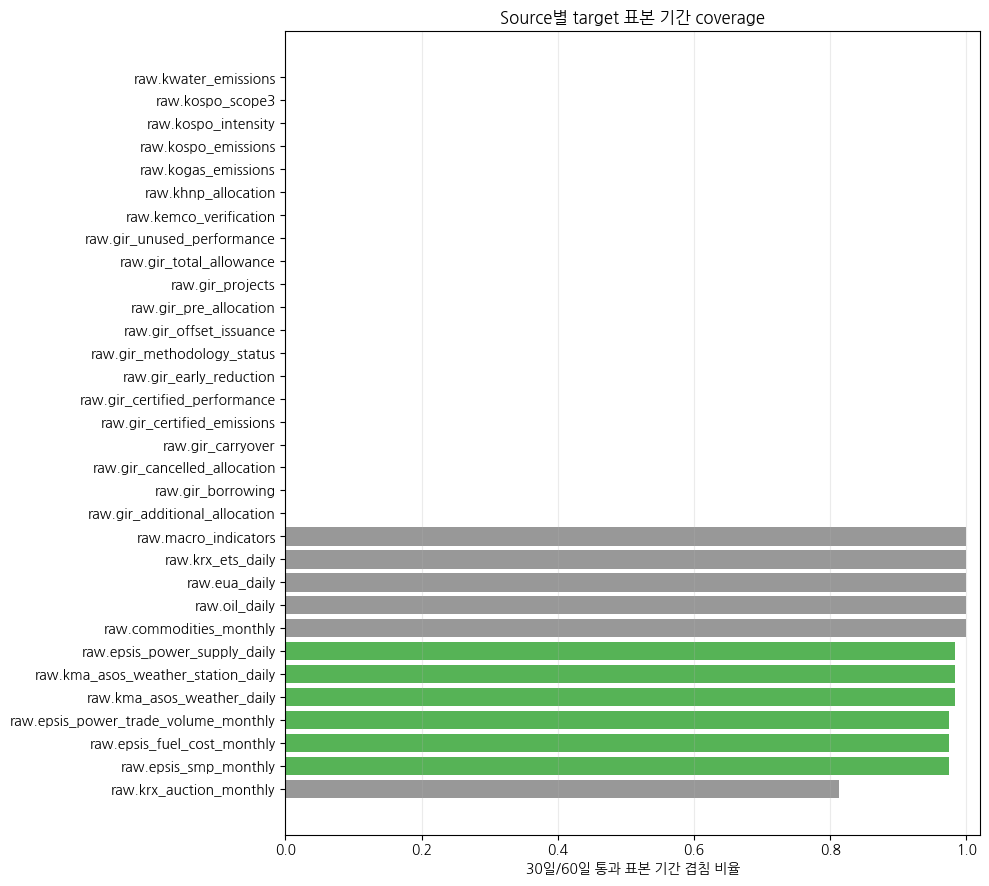

In [4]:
# C04. source별 target sample coverage
def coverage_between_dates(dates: pd.Series, start, end):
    if pd.isna(start) or pd.isna(end) or len(dates) == 0:
        return np.nan
    return float(dates.between(pd.Timestamp(start), pd.Timestamp(end)).mean())

coverage_rows = []
for _, row in source_inventory.iterrows():
    start, end = row.get('period_start'), row.get('period_end')
    coverage_rows.append({
        'source_table': row['source_table'],
        'data_category': row.get('data_category'),
        'frequency': row.get('frequency'),
        'period_start': start,
        'period_end': end,
        'row_count_live': row.get('row_count_live'),
        'window_coverage_all': coverage_between_dates(target['trd_dd'], start, end),
        'window_coverage_30d': coverage_between_dates(target.loc[target['pass_30d'], 'trd_dd'], start, end),
        'window_coverage_60d': coverage_between_dates(target.loc[target['pass_60d'], 'trd_dd'], start, end),
        'window_coverage_both': coverage_between_dates(target.loc[target['pass_both_targets'], 'trd_dd'], start, end),
        'has_active_high_rule': bool(row.get('has_active_high_rule')),
        'has_asof_date_rule': bool(row.get('has_asof_date_rule')),
        'disclosure_statuses': row.get('disclosure_statuses'),
        'disclosure_confidences': row.get('disclosure_confidences'),
    })

source_coverage = pd.DataFrame(coverage_rows).sort_values(['window_coverage_both', 'source_table'], ascending=[False, True])
display(source_coverage)

fig, ax = plt.subplots(figsize=(10, max(5, 0.28 * len(source_coverage))))
plot_df = source_coverage.sort_values('window_coverage_both')
colors = np.where(plot_df['has_active_high_rule'], 'tab:green', 'tab:gray')
ax.barh(plot_df['source_table'], plot_df['window_coverage_both'].fillna(0), color=colors, alpha=0.8)
ax.set_xlim(0, 1.02)
ax.set_xlabel('30일/60일 통과 표본 기간 겹침 비율')
ax.set_title('Source별 target 표본 기간 coverage')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / 'source_window_coverage.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Join rule 및 readiness status

Source별 join rule과 readiness status를 부여한다. 이 단계에서는 피처 중요도를 판단하지 않고, 예측 시점에서 사용할 수 있는 후보 범위를 정리한다.

| status | 의미 |
|---|---|
| `use_now` | `asof_date` 또는 공시 규칙이 metadata에 명확하게 등록되어 있어 우선 투입할 수 있는 source이다. |
| `derive_now` | raw source에서 rolling, lag, spread 등 파생 계산을 만든 뒤 투입할 수 있는 source이다. |
| `use_with_lag` | lag 또는 as-of join을 적용해 투입할 수 있는 source이다. |
| `review_required` | 공시 시점, 발표 주기, source timing 검토가 필요한 source이다. |
| `not_available` | reference에는 있으나 현재 DB에서 source가 확인되지 않은 후보이다. |

In [5]:
# C05. join rule 및 readiness status 부여
def classify_feature_group(table_name: str):
    if table_name == 'krx_ets_daily':
        return 'market_internal'
    if table_name == 'krx_auction_monthly':
        return 'auction'
    if table_name in ['oil_daily', 'commodities_monthly', 'eua_daily']:
        return 'external_market'
    if table_name == 'macro_indicators':
        return 'macro_financial'
    if table_name.startswith('epsis_'):
        return 'power_epsis'
    if table_name.startswith('kma_'):
        return 'weather_kma'
    if table_name.startswith('gir_'):
        return 'gir_supply_compliance'
    if table_name.startswith(('kogas_', 'kospo_', 'khnp_', 'kwater_', 'kemco_')):
        return 'public_emissions_power'
    return 'other_raw'

def infer_join_rule(row):
    table = row['table_name']
    freq = str(row.get('frequency') or '').lower()
    primary_date = row.get('primary_date_column')
    asof_cols = str(row.get('asof_date_columns') or '')
    active_high = bool(row.get('has_active_high_rule'))
    group = classify_feature_group(table)
    if group == 'market_internal':
        return 'trade_date 기준 market-level 집계 후 lag/rolling 파생. target horizon의 미래 가격/거래량은 사용 금지.'
    if active_high and asof_cols:
        return 'asof_date <= trade_date 기준 as-of join.'
    if 'daily' in freq:
        return f'{primary_date or "date"} <= trade_date 기준 lag/as-of join. same-day 사용 가능성은 source timing 검토 필요.'
    if 'month' in freq or 'monthly' in freq:
        return f'{primary_date or "month"} 기준 월별 값 forward-fill. 공시 lag/asof_date가 없으면 보수적 lag 필요.'
    if 'year' in freq or 'annual' in freq:
        return 'annual/period value는 period_start 또는 annual_t+1 규칙 검토 후 forward-fill.'
    return 'source-specific join rule review required.'

def infer_readiness(row):
    table = row['table_name']
    group = classify_feature_group(table)
    active_high = bool(row.get('has_active_high_rule'))
    asof = bool(row.get('has_asof_date_rule'))
    freq = str(row.get('frequency') or '').lower()
    if group == 'market_internal':
        return 'derive_now'
    if active_high and asof:
        return 'use_now'
    if group in ['external_market', 'auction']:
        return 'use_with_lag'
    if group in ['macro_financial', 'gir_supply_compliance', 'public_emissions_power']:
        return 'review_required'
    if 'monthly' in freq or 'annual' in freq:
        return 'review_required'
    return 'review_required'

join_rules = source_inventory.copy()
join_rules['feature_group'] = join_rules['table_name'].map(classify_feature_group)
join_rules['join_rule'] = join_rules.apply(infer_join_rule, axis=1)
join_rules['readiness_status'] = join_rules.apply(infer_readiness, axis=1)
join_rules['main_model_candidate'] = join_rules['readiness_status'].isin(['use_now', 'derive_now', 'use_with_lag'])
join_rules = join_rules[[
    'source_table', 'feature_group', 'frequency', 'primary_date_column', 'feature_date_columns',
    'asof_date_columns', 'usable_date_rules', 'has_active_high_rule', 'disclosure_statuses',
    'join_rule', 'readiness_status', 'main_model_candidate', 'notes'
]].sort_values(['readiness_status', 'feature_group', 'source_table'])

display(join_rules)
join_rules.to_csv(OUT_TABLE_DIR / 'feature_join_rules.csv', index=False, encoding='utf-8-sig')

,source_table,feature_group,frequency,primary_date_column,feature_date_columns,asof_date_columns,usable_date_rules,has_active_high_rule,disclosure_statuses,join_rule,readiness_status,main_model_candidate,notes
28,raw.krx_ets_daily,market_internal,daily,trd_dd,trd_dd,,Review source publication timing before featur...,False,requires_review,trade_date 기준 market-level 집계 후 lag/rolling 파생...,derive_now,True,NaN
6,raw.gir_additional_allocation,gir_supply_compliance,annual,year,year,,Review source publication timing before featur...,False,requires_review,annual/period value는 period_start 또는 annual_t+...,review_required,False,NaN
7,raw.gir_borrowing,gir_supply_compliance,annual,year,year,,Review source publication timing before featur...,False,requires_review,annual/period value는 period_start 또는 annual_t+...,review_required,False,NaN
8,raw.gir_cancelled_allocation,gir_supply_compliance,annual,year,year,,Review source publication timing before featur...,False,requires_review,annual/period value는 period_start 또는 annual_t+...,review_required,False,NaN
9,raw.gir_carryover,gir_supply_compliance,mixed,year,year,,Review source publication timing before featur...,False,requires_review,source-specific join rule review required.,review_required,False,NaN
10,raw.gir_certified_emissions,gir_supply_compliance,annual,year,year,,Review source publication timing before featur...,False,requires_review,annual/period value는 period_start 또는 annual_t+...,review_required,False,NaN
11,raw.gir_certified_performance,gir_supply_compliance,annual,NaN,,,Review source publication timing before featur...,False,requires_review,annual/period value는 period_start 또는 annual_t+...,review_required,False,NaN
12,raw.gir_early_reduction,gir_supply_compliance,annual,year,year,,Review source publication timing before featur...,False,requires_review,annual/period value는 period_start 또는 annual_t+...,review_required,False,NaN
13,raw.gir_methodology_status,gir_supply_compliance,annual,NaN,,,Review source publication timing before featur...,False,requires_review,annual/period value는 period_start 또는 annual_t+...,review_required,False,NaN
14,raw.gir_offset_issuance,gir_supply_compliance,annual,year,year,,Review source publication timing before featur...,False,requires_review,annual/period value는 period_start 또는 annual_t+...,review_required,False,NaN


## 6. DB raw column 기반 wide feature 후보 catalog

Raw table의 숫자형/불리언 컬럼을 넓게 후보로 잡는다. ID, ingestion metadata, 텍스트, 날짜 컬럼은 제외한다. \
컬럼명은 분석용 schema를 유지하고, 표시용 한글명은 필요한 표에서 별도 `*_display` 객체로 만든다.

In [6]:
# C06. raw column 기반 wide feature 후보 catalog
numeric_type_tokens = ['int', 'numeric', 'decimal', 'double', 'real', 'float', 'bigint', 'smallint']
boolean_type_tokens = ['bool']

def is_candidate_column(row):
    col = str(row['column_name']).lower()
    dtype = str(row.get('db_data_type') or '').lower()
    if col == 'id' or col.endswith('_id'):
        return False
    if any(tok in col for tok in ['created_at', 'updated_at', 'loaded_at', 'source_file', 'file_name']):
        return False
    if col in ['year', 'month', 'date', 'period', 'trd_dd', 'feature_date', 'asof_date']:
        return False
    if col.endswith('_date') or col.endswith('_month') or col.endswith('_year'):
        return False
    is_numeric = any(tok in dtype for tok in numeric_type_tokens)
    is_boolean = any(tok in dtype for tok in boolean_type_tokens) or col.startswith(('is_', 'has_')) or col.endswith('_flag')
    return is_numeric or is_boolean

candidate_cols = column_catalog[column_catalog.apply(is_candidate_column, axis=1)].copy()
source_status = source_inventory[['schema_name', 'table_name', 'source_table']].copy()
source_status['feature_group'] = source_status['table_name'].map(classify_feature_group)
source_status['join_rule'] = source_inventory.apply(infer_join_rule, axis=1)
source_status['readiness_status'] = source_inventory.apply(infer_readiness, axis=1)
source_status['main_model_candidate'] = source_status['readiness_status'].isin(['use_now', 'derive_now', 'use_with_lag'])

feature_candidate_catalog = candidate_cols.merge(source_status, on=['schema_name', 'table_name'], how='left')
feature_candidate_catalog['feature_name'] = (
    feature_candidate_catalog['table_name'].str.replace(r'[^0-9a-zA-Z_]+', '_', regex=True)
    + '__'
    + feature_candidate_catalog['column_name'].str.replace(r'[^0-9a-zA-Z_]+', '_', regex=True)
)
feature_candidate_catalog['candidate_type'] = np.where(
    feature_candidate_catalog['readiness_status'].eq('derive_now'), 'raw_or_derived_source', 'raw_numeric_column'
)
feature_candidate_catalog = feature_candidate_catalog.rename(columns={'column_name': 'source_column'})
feature_candidate_catalog = feature_candidate_catalog[[
    'feature_group', 'candidate_type', 'feature_name', 'source_table', 'table_name', 'source_column',
    'db_data_type', 'unit', 'description_ko', 'join_rule', 'readiness_status', 'main_model_candidate'
]]

print(f'raw numeric/boolean feature candidates: {len(feature_candidate_catalog):,}')
display(feature_candidate_catalog.head(30))

raw numeric/boolean feature candidates: 140


,feature_group,candidate_type,feature_name,source_table,table_name,source_column,db_data_type,unit,description_ko,join_rule,readiness_status,main_model_candidate
0,external_market,raw_numeric_column,commodities_monthly__lng_japan,raw.commodities_monthly,commodities_monthly,lng_japan,numeric,NaN,NaN,date 기준 월별 값 forward-fill. 공시 lag/asof_date가 없...,use_with_lag,True
1,external_market,raw_numeric_column,commodities_monthly__natgas_europe,raw.commodities_monthly,commodities_monthly,natgas_europe,numeric,NaN,NaN,date 기준 월별 값 forward-fill. 공시 lag/asof_date가 없...,use_with_lag,True
2,external_market,raw_numeric_column,commodities_monthly__coal_newcastle,raw.commodities_monthly,commodities_monthly,coal_newcastle,numeric,NaN,NaN,date 기준 월별 값 forward-fill. 공시 lag/asof_date가 없...,use_with_lag,True
3,power_epsis,raw_numeric_column,epsis_fuel_cost_monthly__fuel_price_nuclear_kr...,raw.epsis_fuel_cost_monthly,epsis_fuel_cost_monthly,fuel_price_nuclear_krw_per_kwh,numeric,NaN,NaN,asof_date <= trade_date 기준 as-of join.,use_now,True
4,power_epsis,raw_numeric_column,epsis_fuel_cost_monthly__fuel_price_bituminous...,raw.epsis_fuel_cost_monthly,epsis_fuel_cost_monthly,fuel_price_bituminous_coal_krw_per_ton,numeric,NaN,NaN,asof_date <= trade_date 기준 as-of join.,use_now,True
5,power_epsis,raw_numeric_column,epsis_fuel_cost_monthly__fuel_price_anthracite...,raw.epsis_fuel_cost_monthly,epsis_fuel_cost_monthly,fuel_price_anthracite_krw_per_ton,numeric,NaN,NaN,asof_date <= trade_date 기준 as-of join.,use_now,True
6,power_epsis,raw_numeric_column,epsis_fuel_cost_monthly__fuel_price_oil_krw_pe...,raw.epsis_fuel_cost_monthly,epsis_fuel_cost_monthly,fuel_price_oil_krw_per_kl,numeric,NaN,NaN,asof_date <= trade_date 기준 as-of join.,use_now,True
7,power_epsis,raw_numeric_column,epsis_fuel_cost_monthly__fuel_price_lng_krw_pe...,raw.epsis_fuel_cost_monthly,epsis_fuel_cost_monthly,fuel_price_lng_krw_per_ton,numeric,NaN,NaN,asof_date <= trade_date 기준 as-of join.,use_now,True
8,power_epsis,raw_numeric_column,epsis_fuel_cost_monthly__heat_price_nuclear_kr...,raw.epsis_fuel_cost_monthly,epsis_fuel_cost_monthly,heat_price_nuclear_krw_per_gcal,numeric,NaN,NaN,asof_date <= trade_date 기준 as-of join.,use_now,True
9,power_epsis,raw_numeric_column,epsis_fuel_cost_monthly__heat_price_bituminous...,raw.epsis_fuel_cost_monthly,epsis_fuel_cost_monthly,heat_price_bituminous_coal_krw_per_gcal,numeric,NaN,NaN,asof_date <= trade_date 기준 as-of join.,use_now,True


## 7. Reference 기반 파생 feature mapping

`docs/reference/피처_엔지니어링.md`와 `docs/reference/가격_모델.md`의 feature 아이디어를 현재 DB source와 매핑한다. \
DB source가 확인되지 않은 항목은 future work 후보로 분리한다.

In [7]:
# C07. reference 기반 파생 feature mapping
table_set = set(source_inventory['source_table'])

def availability(source_tables):
    if not source_tables:
        return 'not_available'
    present = [t for t in source_tables if t in table_set]
    if len(present) == len(source_tables):
        return 'available'
    if present:
        return 'partial'
    return 'not_available'

reference_rows = [
    ['market_internal', 'lagged market_vwap / log return / momentum / realized volatility', ['raw.krx_ets_daily'], '가격_모델.md: VWAP, 유동성, 기술적 지표; 피처_엔지니어링.md: 시차 피처', 'derive_now', 'target horizon의 미래 가격/거래량은 제외하고 기준일 이전 rolling/lag만 사용한다.'],
    ['market_internal', 'blended day, n_vintages, vwap_range, liquidity flags', ['raw.krx_ets_daily'], '가격_모델.md: 빈티지/유동성 부족 처리', 'derive_now', 'current-day 또는 lagged 형태를 명확히 구분한다.'],
    ['auction_policy', 'auction volume, auction price, auction proximity', ['raw.krx_auction_monthly'], '피처_엔지니어링.md: 공급/정책 변수, 경매 공급량 조정', 'use_with_lag', '월별/경매일 기준 사용 가능일 검토 후 forward-fill한다.'],
    ['energy_spread', 'clean spark spread', ['raw.epsis_smp_monthly', 'raw.epsis_fuel_cost_monthly', 'raw.krx_ets_daily'], '피처_엔지니어링.md: CSS = P_elec - gas cost - carbon cost', 'derive_now', 'EPSIS monthly asof rule과 market_vwap lag/asof 기준을 맞춘다.'],
    ['energy_spread', 'clean dark spread', ['raw.epsis_smp_monthly', 'raw.epsis_fuel_cost_monthly', 'raw.krx_ets_daily'], '피처_엔지니어링.md: CDS = P_elec - coal cost - carbon cost', 'derive_now', 'fuel_cost 테이블에서 석탄/LNG 구분 가능성을 확인해야 한다.'],
    ['energy_spread', 'fuel switching price / spread gap', ['raw.epsis_smp_monthly', 'raw.epsis_fuel_cost_monthly'], '피처_엔지니어링.md: fuel switching price', 'derive_now', 'heat rate/emission factor 상수 또는 외부 reference가 필요할 수 있다.'],
    ['power_epsis', 'power supply, generation mix proxy, power trade volume', ['raw.epsis_power_supply_daily', 'raw.epsis_power_trade_volume_monthly'], '피처_엔지니어링.md: 전력 생산/수요와 탄소 수요 연결', 'use_now', 'active/high asof rule이 있으므로 우선 후보로 둔다.'],
    ['weather', 'HDD/CDD, temperature anomaly, precipitation, wind rolling features', ['raw.kma_asos_weather_daily', 'raw.kma_asos_weather_station_daily'], '피처_엔지니어링.md: HDD/CDD, 기온/강수/풍속', 'derive_now', 'KMA daily asof rule을 적용하고 anomaly는 과거 정보만으로 계산한다.'],
    ['macro_financial', 'KOSPI, USD/KRW, rates, industrial/macro indicators', ['raw.macro_indicators'], '피처_엔지니어링.md, 가격_모델.md: 거시경제/금융시장 지표', 'review_required', 'source별 발표일/빈도 확인 후 lag 적용이 필요하다.'],
    ['external_market', 'oil/LNG/coal/commodity prices, returns, volatility', ['raw.oil_daily', 'raw.commodities_monthly'], '피처_엔지니어링.md: 에너지 가격, 원자재 가격', 'use_with_lag', '일별 시장가격은 lag/asof 기준을 명확히 두고 월별 commodity는 보수적 lag를 적용한다.'],
    ['external_market', 'EUA price/return/volatility, KAU-EUA spread', ['raw.eua_daily', 'raw.krx_ets_daily'], '피처_엔지니어링.md: 글로벌 탄소시장/CBAM 연계', 'derive_now', 'time zone과 장마감 기준을 보수적으로 처리하기 위해 최소 1일 lag 후보를 함께 만든다.'],
    ['gir_supply_compliance', 'total allowance, pre-allocation, certified emissions, carryover, borrowing, offset ratios', ['raw.gir_total_allowance', 'raw.gir_pre_allocation', 'raw.gir_certified_emissions', 'raw.gir_carryover', 'raw.gir_borrowing', 'raw.gir_offset_issuance'], '피처_엔지니어링.md, 가격_모델.md: 공급/수급/제도 변수', 'review_required', 'period_start와 annual_t+1을 구분해야 한다. 같은 연도 실제값을 1월부터 붙이면 leakage다.'],
    ['policy_regime', 'phase dummy, compliance month dummy, 4기/MSR dummy, distance-to-threshold', ['raw.krx_ets_daily', 'raw.krx_auction_monthly', 'raw.gir_total_allowance'], '피처_엔지니어링.md: 정책 충격, compliance cycle, MSR', 'derive_now', '날짜/제도 rule 기반 파생. 정책 event 날짜가 별도 DB에 없으면 rule-based dummy부터 시작한다.'],
    ['credit_spread', 'KAU-KOC/KCU spread', [], '피처_엔지니어링.md: KAU, KCU, KOC 간 스프레드', 'not_available', '현재 확인된 raw table에는 KOC/KCU 가격 source가 없다.'],
    ['sentiment_attention', 'Naver/Google search index, news sentiment, topic intensity', [], '피처_엔지니어링.md: 검색지수/뉴스 정서', 'not_available', '현재 DB source 없음. future work로 분리한다.'],
    ['decomposition', 'EMD/VMD/CEEMDAN/IMF features', ['raw.krx_ets_daily'], '피처_엔지니어링.md, 가격_모델.md: 신호 분해 기반 모델', 'review_required', '분해가 full-sample로 계산되면 leakage 가능성이 높다. walk-forward 내부에서만 계산해야 하므로 초기 baseline에서는 보류한다.'],
]

reference_mapping = pd.DataFrame(reference_rows, columns=['reference_group', 'reference_feature', 'source_tables', 'reference_basis', 'recommended_status', 'notes'])
reference_mapping['candidate_source_tables'] = reference_mapping['source_tables'].map(lambda xs: '; '.join(xs) if xs else '')
reference_mapping['db_availability'] = reference_mapping['source_tables'].map(availability)
reference_mapping['readiness_status'] = reference_mapping.apply(lambda r: r['recommended_status'] if r['db_availability'] != 'not_available' else 'not_available', axis=1)
reference_mapping['main_model_candidate'] = reference_mapping['readiness_status'].isin(['use_now', 'derive_now', 'use_with_lag'])
reference_mapping = reference_mapping.drop(columns=['source_tables'])

display(reference_mapping)
reference_mapping.to_csv(OUT_TABLE_DIR / 'reference_feature_candidate_mapping.csv', index=False, encoding='utf-8-sig')

,reference_group,reference_feature,reference_basis,recommended_status,notes,candidate_source_tables,db_availability,readiness_status,main_model_candidate
0,market_internal,lagged market_vwap / log return / momentum / r...,"가격_모델.md: VWAP, 유동성, 기술적 지표; feature-en...",derive_now,target horizon의 미래 가격/거래량은 제외하고 기준일 이전 rolling...,raw.krx_ets_daily,available,derive_now,True
1,market_internal,"blended day, n_vintages, vwap_range, liquidity...",가격_모델.md: 빈티지/유동성 부족 처리,derive_now,current-day 또는 lagged 형태를 명확히 구분한다.,raw.krx_ets_daily,available,derive_now,True
2,auction_policy,"auction volume, auction price, auction proximity","피처_엔지니어링.md: 공급/정책 변수, 경매 공급량 조정",use_with_lag,월별/경매일 기준 사용 가능일 검토 후 forward-fill한다.,raw.krx_auction_monthly,available,use_with_lag,True
3,energy_spread,clean spark spread,피처_엔지니어링.md: CSS = P_elec - gas cos...,derive_now,EPSIS monthly asof rule과 market_vwap lag/asof ...,raw.epsis_smp_monthly; raw.epsis_fuel_cost_mon...,available,derive_now,True
4,energy_spread,clean dark spread,피처_엔지니어링.md: CDS = P_elec - coal co...,derive_now,fuel_cost 테이블에서 석탄/LNG 구분 가능성을 확인해야 한다.,raw.epsis_smp_monthly; raw.epsis_fuel_cost_mon...,available,derive_now,True
5,energy_spread,fuel switching price / spread gap,피처_엔지니어링.md: fuel switching price,derive_now,heat rate/emission factor 상수 또는 외부 reference가 ...,raw.epsis_smp_monthly; raw.epsis_fuel_cost_mon...,available,derive_now,True
6,power_epsis,"power supply, generation mix proxy, power trad...",피처_엔지니어링.md: 전력 생산/수요와 탄소 수요 연결,use_now,active/high asof rule이 있으므로 우선 후보로 둔다.,raw.epsis_power_supply_daily; raw.epsis_power_...,available,use_now,True
7,weather,"HDD/CDD, temperature anomaly, precipitation, w...","피처_엔지니어링.md: HDD/CDD, 기온/강수/풍속",derive_now,KMA daily asof rule을 적용하고 anomaly는 과거 정보만으로 계산한다.,raw.kma_asos_weather_daily; raw.kma_asos_weath...,available,derive_now,True
8,macro_financial,"KOSPI, USD/KRW, rates, industrial/macro indica...","피처_엔지니어링.md, 가격_모델.md: 거시경제/...",review_required,source별 발표일/빈도 확인 후 lag 적용이 필요하다.,raw.macro_indicators,available,review_required,False
9,external_market,"oil/LNG/coal/commodity prices, returns, volati...","피처_엔지니어링.md: 에너지 가격, 원자재 가격",use_with_lag,일별 시장가격은 lag/asof 기준을 명확히 두고 월별 commodity는 보수적...,raw.oil_daily; raw.commodities_monthly,available,use_with_lag,True


## 8. Readiness scorecard 및 wide feature policy

DB source inventory, raw column 후보, reference mapping을 합쳐 첫 wide feature set의 범위를 요약한다. 이 요약은 다음 노트북에서 실제 feature matrix를 만들 때 입력 catalog로 사용한다.

파일로 저장하는 항목은 다음 단계에 필요한 핵심 산출물로 제한한다.

,readiness_status,source_count,raw_column_candidate_count
0,use_now,6,69
1,derive_now,1,9
2,use_with_lag,4,19
3,review_required,21,43
4,not_available,0,0


,feature_group,readiness_status,source_count,raw_column_candidate_count
0,auction,use_now,0,0
1,auction,derive_now,0,0
2,auction,use_with_lag,1,9
3,auction,review_required,0,0
4,auction,not_available,0,0
5,external_market,use_now,0,0
6,external_market,derive_now,0,0
7,external_market,use_with_lag,3,10
8,external_market,review_required,0,0
9,external_market,not_available,0,0


,readiness_status,reference_candidate_count
0,derive_now,8
1,not_available,2
2,review_required,3
3,use_now,1
4,use_with_lag,2


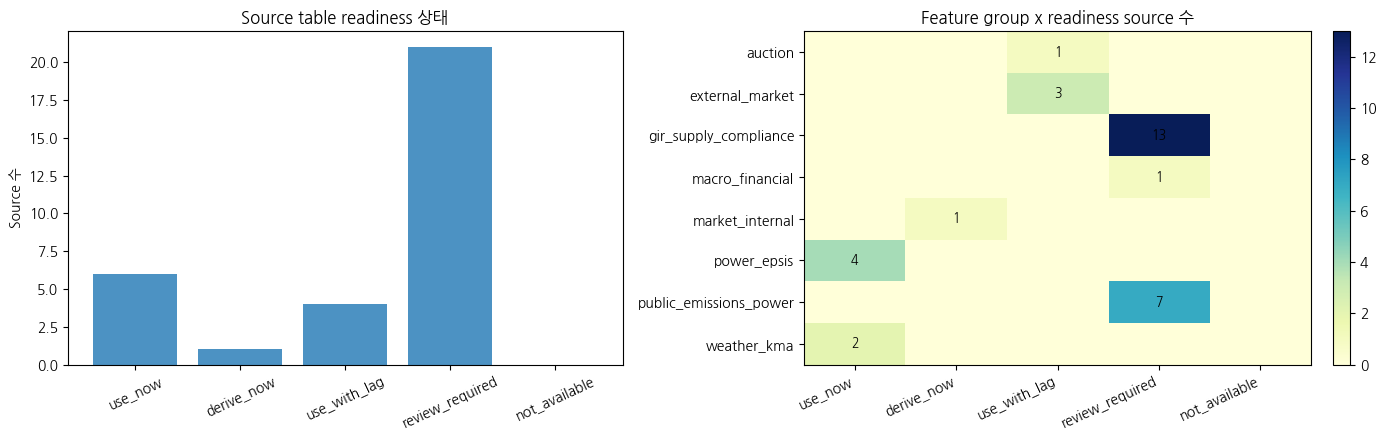

,artifact,path
0,wide feature policy,outputs/tables/feature_readiness/wide_feature_...
1,first wide candidates,outputs/tables/feature_readiness/first_wide_fe...
2,review required candidates,outputs/tables/feature_readiness/review_requir...
3,report,reports/feature_readiness/report.md


In [8]:
# C08. readiness scorecard 및 wide feature policy
source_scorecard = join_rules.copy()
source_scorecard['candidate_level'] = 'source_table'
source_scorecard['candidate_count'] = source_scorecard['source_table'].map(feature_candidate_catalog.groupby('source_table').size().to_dict()).fillna(0).astype(int)

status_order = pd.CategoricalDtype(['use_now', 'derive_now', 'use_with_lag', 'review_required', 'not_available'], ordered=True)
source_scorecard['readiness_status'] = source_scorecard['readiness_status'].astype(status_order)
source_scorecard = source_scorecard.sort_values(['readiness_status', 'feature_group', 'source_table'])

status_summary = source_scorecard.groupby(['readiness_status'], observed=False).agg(
    source_count=('source_table', 'size'), raw_column_candidate_count=('candidate_count', 'sum')
).reset_index()
group_status_summary = source_scorecard.groupby(['feature_group', 'readiness_status'], observed=False).agg(
    source_count=('source_table', 'size'), raw_column_candidate_count=('candidate_count', 'sum')
).reset_index()
reference_status_summary = reference_mapping.groupby(['readiness_status'], observed=False).agg(
    reference_candidate_count=('reference_feature', 'size')
).reset_index()

display(status_summary)
display(group_status_summary)
display(reference_status_summary)

source_scorecard.to_csv(OUT_TABLE_DIR / 'feature_readiness_scorecard.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(status_summary['readiness_status'].astype(str), status_summary['source_count'], color='tab:blue', alpha=0.8)
axes[0].set_title('Source table readiness 상태')
axes[0].set_ylabel('Source 수')
axes[0].tick_params(axis='x', rotation=25)

pivot = group_status_summary.pivot(index='feature_group', columns='readiness_status', values='source_count').fillna(0)
im = axes[1].imshow(pivot.values, aspect='auto', cmap='YlGnBu')
axes[1].set_xticks(np.arange(len(pivot.columns)))
axes[1].set_xticklabels([str(c) for c in pivot.columns], rotation=25, ha='right')
axes[1].set_yticks(np.arange(len(pivot.index)))
axes[1].set_yticklabels(pivot.index)
axes[1].set_title('Feature group x readiness source 수')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = int(pivot.iloc[i, j])
        if val:
            axes[1].text(j, i, str(val), ha='center', va='center', color='black', fontsize=9)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / 'readiness_status_overview.png', dpi=160, bbox_inches='tight')
plt.show()

use_now_sources = source_scorecard.loc[source_scorecard['readiness_status'].astype(str).eq('use_now'), 'source_table'].tolist()
derive_now_sources = source_scorecard.loc[source_scorecard['readiness_status'].astype(str).eq('derive_now'), 'source_table'].tolist()
use_with_lag_sources = source_scorecard.loc[source_scorecard['readiness_status'].astype(str).eq('use_with_lag'), 'source_table'].tolist()
review_sources = source_scorecard.loc[source_scorecard['readiness_status'].astype(str).eq('review_required'), 'source_table'].tolist()
main_candidates = feature_candidate_catalog.loc[feature_candidate_catalog['main_model_candidate']].copy()
review_candidates = feature_candidate_catalog.loc[~feature_candidate_catalog['main_model_candidate']].copy()

wide_feature_policy = {
    'include_in_first_wide_set': {
        'use_now_sources': use_now_sources,
        'derive_now_sources': derive_now_sources,
        'use_with_lag_sources': use_with_lag_sources,
        'raw_column_candidate_count': int(len(main_candidates)),
    },
    'hold_for_disclosure_review': {
        'review_required_sources': review_sources,
        'raw_column_candidate_count': int(len(review_candidates)),
    },
    'reference_only_not_available': reference_mapping.loc[reference_mapping['readiness_status'].eq('not_available'), 'reference_feature'].tolist(),
    'target_sample': target_summary,
}

policy_path = OUT_TABLE_DIR / 'wide_feature_policy_summary.json'
first_candidate_path = OUT_TABLE_DIR / 'first_wide_feature_candidates.csv'
review_candidate_path = OUT_TABLE_DIR / 'review_required_feature_candidates.csv'
report_path = REPORT_DIR / 'report.md'

policy_path.write_text(json.dumps(wide_feature_policy, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
main_candidates.to_csv(first_candidate_path, index=False, encoding='utf-8-sig')
review_candidates.to_csv(review_candidate_path, index=False, encoding='utf-8-sig')

report_lines = [
    '# Feature readiness 요약',
    '',
    f'- Target period: {target_summary["date_start"]} ~ {target_summary["date_end"]}',
    f'- Target rows: {target_summary["n_rows"]:,}',
    f'- pass_30d: {target_summary["pass_30d"]:,}',
    f'- pass_60d: {target_summary["pass_60d"]:,}',
    f'- pass_both_targets: {target_summary["pass_both_targets"]:,}',
    '',
    '## Readiness 기준',
    '',
    '- 피처는 가능한 한 넓게 수집한다.',
    '- asof_date, 공시 lag, target horizon 이후 정보 사용 여부는 모델 투입 전에 gate로 점검한다.',
    '- `use_now`, `derive_now`, `use_with_lag`는 첫 wide feature set 후보로 둔다.',
    '- `review_required`는 공시 시점 검토 또는 별도 ablation에서 다룬다.',
    '- `not_available`은 DB source 추가 후 다시 검토한다.',
    '',
    '## 첫 wide feature source 후보',
]
for src_name in use_now_sources + derive_now_sources + use_with_lag_sources:
    report_lines.append(f'- {src_name}')
report_lines.extend(['', '## 공시 lag 검토 필요 source'])
for src_name in review_sources:
    report_lines.append(f'- {src_name}')
report_path.write_text('\n'.join(report_lines) + '\n', encoding='utf-8')

saved_outputs = pd.DataFrame([
    {'artifact': 'wide feature policy', 'path': str(policy_path.relative_to(PROJECT_ROOT))},
    {'artifact': 'first wide candidates', 'path': str(first_candidate_path.relative_to(PROJECT_ROOT))},
    {'artifact': 'review required candidates', 'path': str(review_candidate_path.relative_to(PROJECT_ROOT))},
    {'artifact': 'report', 'path': str(report_path.relative_to(PROJECT_ROOT))},
])
display(saved_outputs)